# Visualize price trends with features (RSI, MA, etc.).

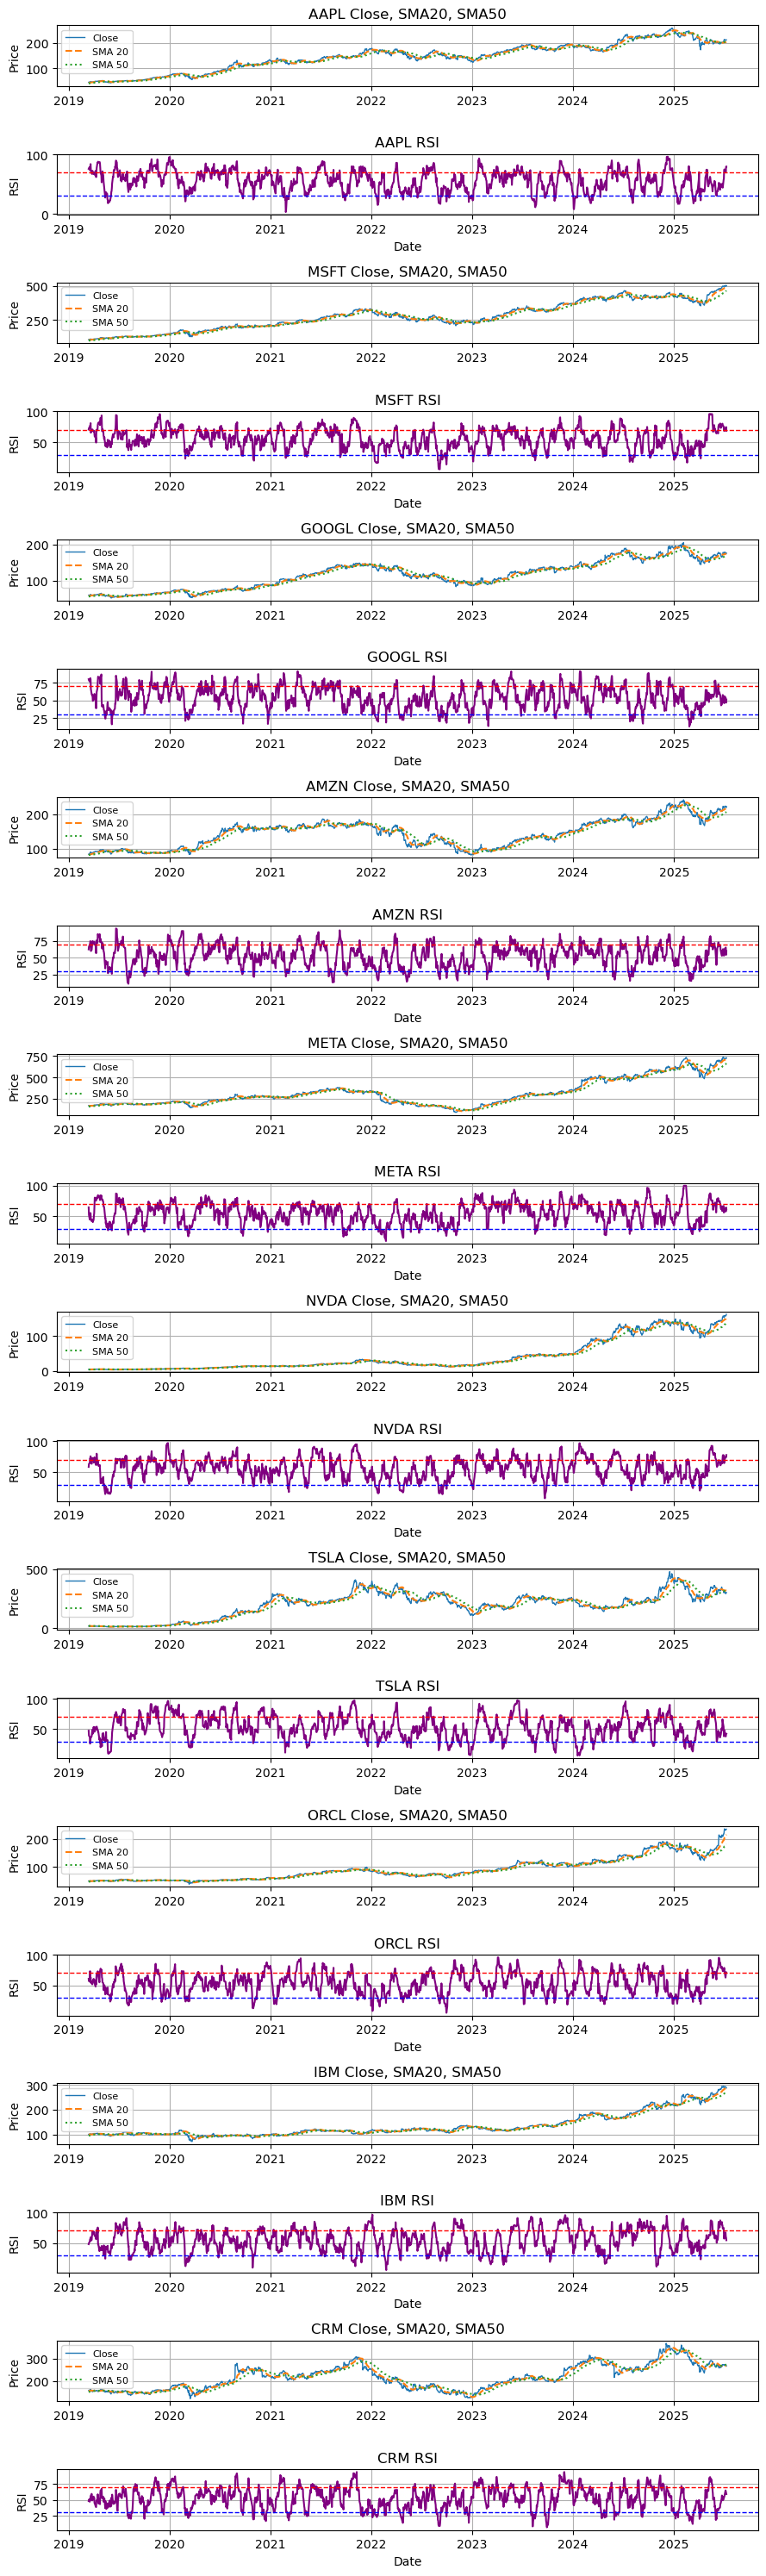

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'ORCL', 'IBM', 'CRM']
engineered_dir = Path("data/engineered")
n_cols = 1
n_rows = (len(tickers) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(n_cols * 9, n_rows * 3), sharex=False)
axes = axes.reshape(n_rows * 2, n_cols)

for idx, ticker in enumerate(tickers):
    row = idx // n_cols
    col = idx % n_cols
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    # close price + moving averages
    ax_price = axes[row * 2, col]
    ax_price.plot(df['Date'], df['Close'], label='Close', linewidth=1)
    ax_price.plot(df['Date'], df['SMA_20'], label='SMA 20', linestyle='--')
    ax_price.plot(df['Date'], df['SMA_50'], label='SMA 50', linestyle=':')
    ax_price.set_title(f'{ticker} Close, SMA20, SMA50')
    ax_price.legend(fontsize=8)
    ax_price.grid(True)
    if col == 0:
        ax_price.set_ylabel('Price')
    ax_rsi = axes[row * 2 + 1, col]
    ax_rsi.plot(df['Date'], df['RSI_14'], label='RSI 14', color='purple')
    ax_rsi.axhline(70, color='red', linestyle='--', linewidth=1)
    ax_rsi.axhline(30, color='blue', linestyle='--', linewidth=1)
    ax_rsi.set_title(f'{ticker} RSI')
    ax_rsi.grid(True)
    if col == 0:
        ax_rsi.set_ylabel('RSI')
    ax_rsi.set_xlabel('Date')

total_plots = n_rows * n_cols
for i in range(len(tickers), total_plots):
    for j in [0, 1]:
        fig.delaxes(axes[(i // n_cols) * 2 + j, i % n_cols])

plt.tight_layout()
plt.show()


# Investigate relationships between stock returns and financial ratios

In [2]:
# calculate average daily return
import numpy as np
returns_summary = []

for ticker in tickers:
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    df = df.sort_values('Date')
    df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
    avg_return = df['Return'].mean()
    returns_summary.append({'Ticker': ticker, 'Avg_Daily_Return': avg_return})

returns_df = pd.DataFrame(returns_summary)
print(returns_df)

  Ticker  Avg_Daily_Return
0   AAPL          0.000990
1   MSFT          0.000964
2  GOOGL          0.000688
3   AMZN          0.000611
4   META          0.000916
5   NVDA          0.002317
6   TSLA          0.001733
7   ORCL          0.001000
8    IBM          0.000663
9    CRM          0.000325


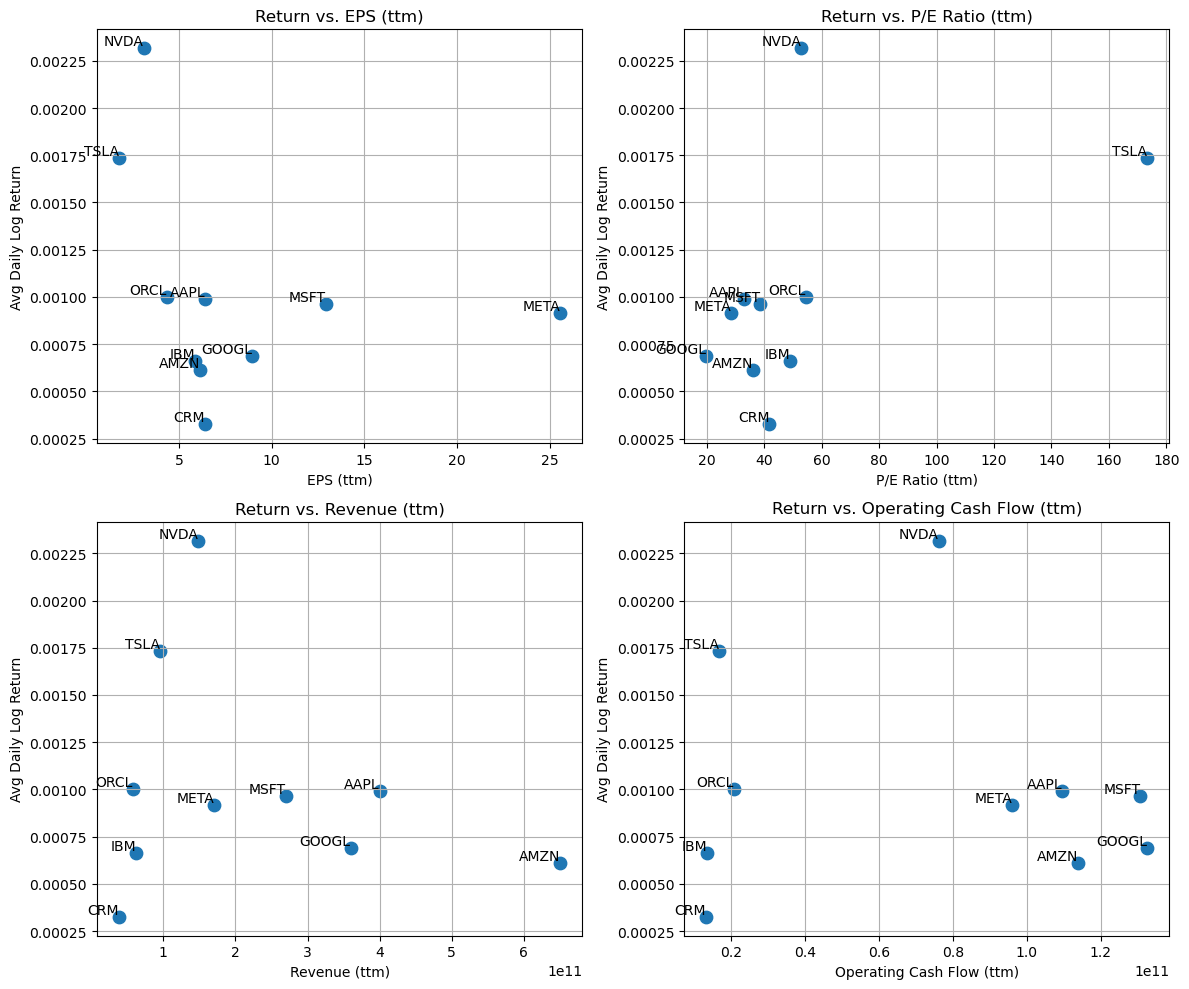

In [3]:
# merge returns with fundamentals + visualize
fundamentals_path = Path("data/raw/tech_fundamentals.csv")
fund_df = pd.read_csv(fundamentals_path)
merged = returns_df.merge(fund_df, on="Ticker")
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
ratios = ["EPS (ttm)", "P/E (ttm)", "Revenue (ttm)", "Operating Cash Flow (ttm)"]
titles = ["EPS (ttm)", "P/E Ratio (ttm)", "Revenue (ttm)", "Operating Cash Flow (ttm)"]

for ax, ratio, title in zip(axs.flatten(), ratios, titles):
    ax.scatter(merged[ratio], merged["Avg_Daily_Return"], s=80)
    for i, row in merged.iterrows():
        ax.text(row[ratio], row["Avg_Daily_Return"], row["Ticker"], fontsize=10, ha='right', va='bottom')
    ax.set_xlabel(title)
    ax.set_ylabel("Avg Daily Log Return")
    ax.set_title(f"Return vs. {title}")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot feature correlations and time series decompositions

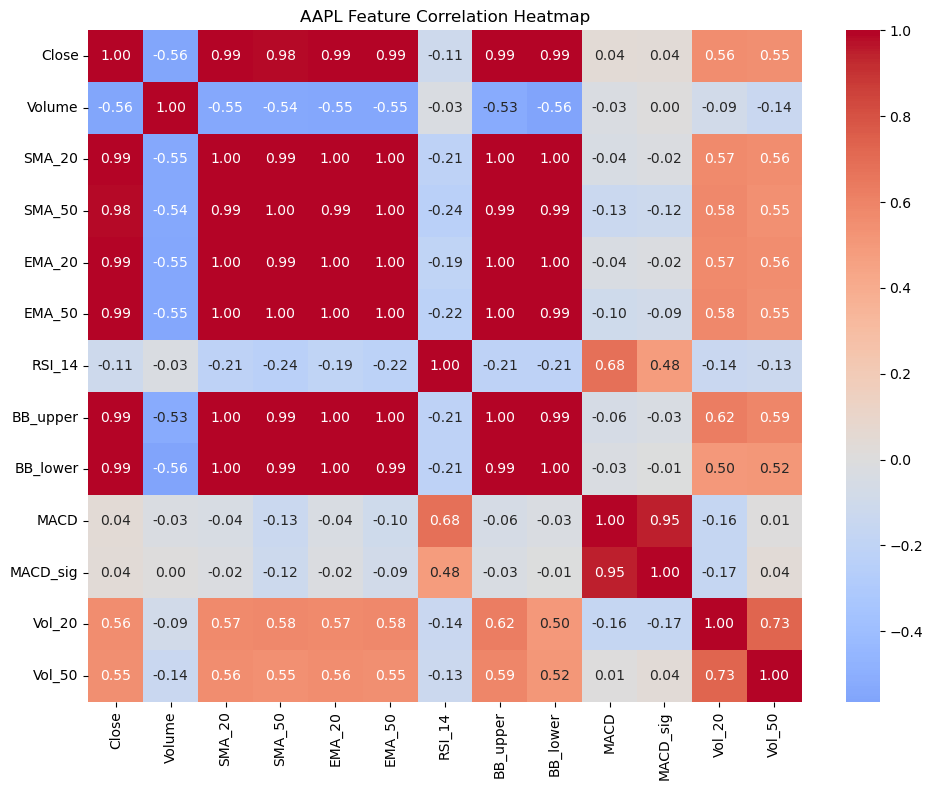

In [4]:
# feature correlation heatmap (for AAPL)
import seaborn as sns

df = pd.read_csv(engineered_dir / "AAPL_engineered.csv", parse_dates=["Date"])
feature_cols = [
    "Close", "Volume", "SMA_20", "SMA_50", "EMA_20", "EMA_50", "RSI_14", 
    "BB_upper", "BB_lower", "MACD", "MACD_sig", "Vol_20", "Vol_50"
]
corr = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("AAPL Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [5]:
# feature correlation heatmaps for All companies
image_dir = Path("image")
image_dir.mkdir(parents=True, exist_ok=True) 

feature_cols = [
    "Close", "Volume", "SMA_20", "SMA_50", "EMA_20", "EMA_50", "RSI_14", 
    "BB_upper", "BB_lower", "MACD", "MACD_sig", "Vol_20", "Vol_50"
]

for ticker in tickers:
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    corr = df[feature_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"{ticker} Feature Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(image_dir / f"{ticker}_feature_corr.png")
    plt.close()
print("Heatmaps saved for all companies in 'image/' folder.")

Heatmaps saved for all companies in 'image/' folder.


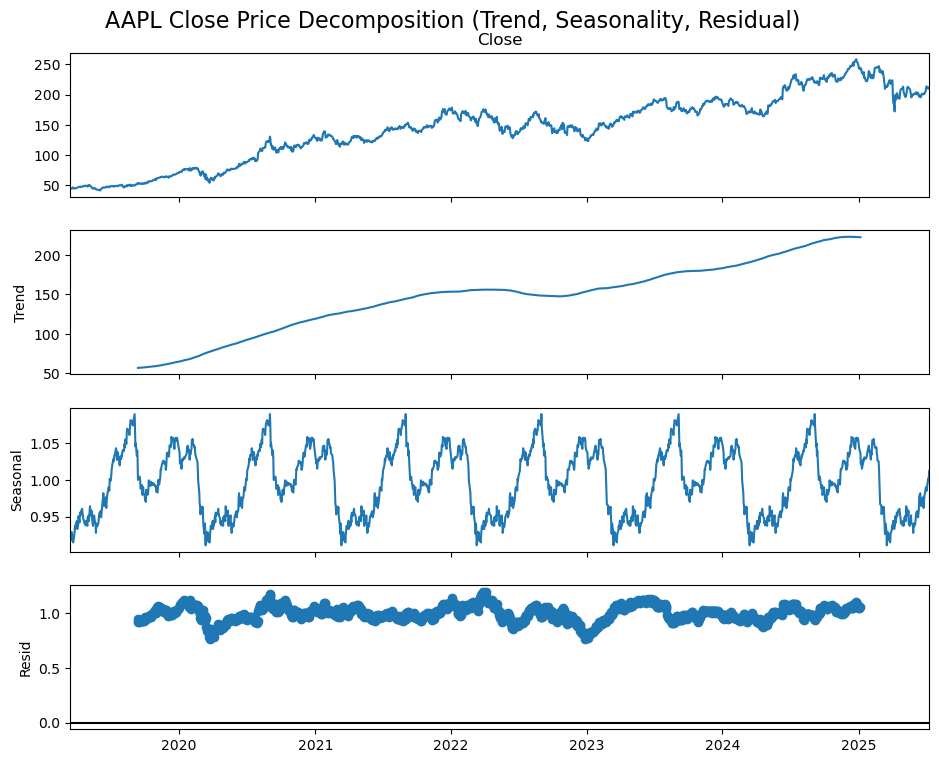

In [6]:
# decompose AAPL’s close price
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv(engineered_dir / "AAPL_engineered.csv", parse_dates=["Date"])
df = df.sort_values("Date")

df.set_index("Date", inplace=True)
result = seasonal_decompose(df["Close"], model="multiplicative", period=252)  # 252 = trading days in a year
fig = result.plot()
fig.set_size_inches(10, 8)
fig.suptitle("AAPL Close Price Decomposition (Trend, Seasonality, Residual)", fontsize=16)
plt.show()

In [7]:
# time series decomposition for All companies
image_dir = Path("image")
image_dir.mkdir(parents=True, exist_ok=True)

for ticker in tickers:
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    df = df.sort_values("Date").set_index("Date")
    result = seasonal_decompose(df["Close"], model="multiplicative", period=252)
    fig = result.plot()
    fig.set_size_inches(10, 8)
    fig.suptitle(f"{ticker} Close Price Decomposition", fontsize=16)
    plt.savefig(image_dir / f"{ticker}_decompose.png")
    plt.close()
print("Decomposition plots saved for all companies in 'image/' folder.")

Decomposition plots saved for all companies in 'image/' folder.


# Identify target variable (e.g., next-day return, price change, classification label)

In [8]:
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

for ticker in tickers:
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    # next-day log return (regression target)
    df['target_next_log_return'] = np.log(df['Close'].shift(-1)) - np.log(df['Close'])
    # classification label
    df['target_up'] = (df['target_next_log_return'] > 0).astype(int) 
    # 1=stock’s closing price went up the next day, 0=down / stayed the same 
    df = df.iloc[:-1].reset_index(drop=True)
    df.to_csv(processed_dir / f"{ticker}_engineered_with_targets.csv", index=False)
    print(f"{ticker}: Targets added and saved to {processed_dir / f'{ticker}_engineered_with_targets.csv'}")

AAPL: Targets added and saved to data/processed/AAPL_engineered_with_targets.csv
MSFT: Targets added and saved to data/processed/MSFT_engineered_with_targets.csv
GOOGL: Targets added and saved to data/processed/GOOGL_engineered_with_targets.csv
AMZN: Targets added and saved to data/processed/AMZN_engineered_with_targets.csv
META: Targets added and saved to data/processed/META_engineered_with_targets.csv
NVDA: Targets added and saved to data/processed/NVDA_engineered_with_targets.csv
TSLA: Targets added and saved to data/processed/TSLA_engineered_with_targets.csv
ORCL: Targets added and saved to data/processed/ORCL_engineered_with_targets.csv
IBM: Targets added and saved to data/processed/IBM_engineered_with_targets.csv
CRM: Targets added and saved to data/processed/CRM_engineered_with_targets.csv


In [9]:
for ticker in tickers:
    file_path = processed_dir / f"{ticker}_engineered_with_targets.csv"
    df = pd.read_csv(file_path, parse_dates=["Date"])
    print(f"\nTicker: {ticker}")
    print(f"Number of rows: {len(df)}")
    print("First 5 rows:")
    print(df.head())


Ticker: AAPL
Number of rows: 1589
First 5 rows:
        Date       Open       High        Low      Close     Volume  \
0 2019-03-14  43.994373  44.042222  43.673806  43.953705   94318000   
1 2019-03-15  44.221651  44.814941  43.956106  44.525471  156171600   
2 2019-03-18  44.448916  45.068521  44.446522  44.980007  104879200   
3 2019-03-19  45.058947  45.212054  44.477616  44.623547  126585600   
4 2019-03-20  44.551792  45.331684  44.192947  45.013508  124140800   

      SMA_20     SMA_50     EMA_20     EMA_50  ...      lag_2      lag_3  \
0  41.821217  39.493815  41.865322  40.338027  ...  43.279076  42.798237   
1  42.004467  39.631968  42.118670  40.502240  ...  43.470474  43.279076   
2  42.214989  39.854151  42.391178  40.677839  ...  43.953705  43.470474   
3  42.401588  40.040287  42.603785  40.832573  ...  44.525471  43.953705   
4  42.594528  40.235794  42.833282  40.996531  ...  44.980007  44.525471   

       lag_5     lag_10  roll_min_20  roll_max_20  roll_mean_20  ro